In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix
import joblib

In [5]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Weatherset/weather.csv')
print(df)

Mounted at /content/drive
            date  precipitation  temp_max  temp_min  wind  weather
0     2012-01-01            0.0      12.8       5.0   4.7  drizzle
1     2012-01-02           10.9      10.6       2.8   4.5     rain
2     2012-01-03            0.8      11.7       7.2   2.3     rain
3     2012-01-04           20.3      12.2       5.6   4.7     rain
4     2012-01-05            1.3       8.9       2.8   6.1     rain
...          ...            ...       ...       ...   ...      ...
1456  2015-12-27            8.6       4.4       1.7   2.9     rain
1457  2015-12-28            1.5       5.0       1.7   1.3     rain
1458  2015-12-29            0.0       7.2       0.6   2.6      fog
1459  2015-12-30            0.0       5.6      -1.0   3.4      sun
1460  2015-12-31            0.0       5.6      -2.1   3.5      sun

[1461 rows x 6 columns]


In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [7]:
#Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

In [8]:
#Encode terger variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['weather_encoded'] = le.fit_transform(df['weather'])

In [ ]:
#Exploratory Data Analysis (EDA

In [9]:
col_name = df.columns
col_name

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather',
       'weather_encoded'],
      dtype='object')

In [10]:
df.nunique()

,0
date,1461
precipitation,111
temp_max,67
temp_min,55
wind,79
weather,5
weather_encoded,5


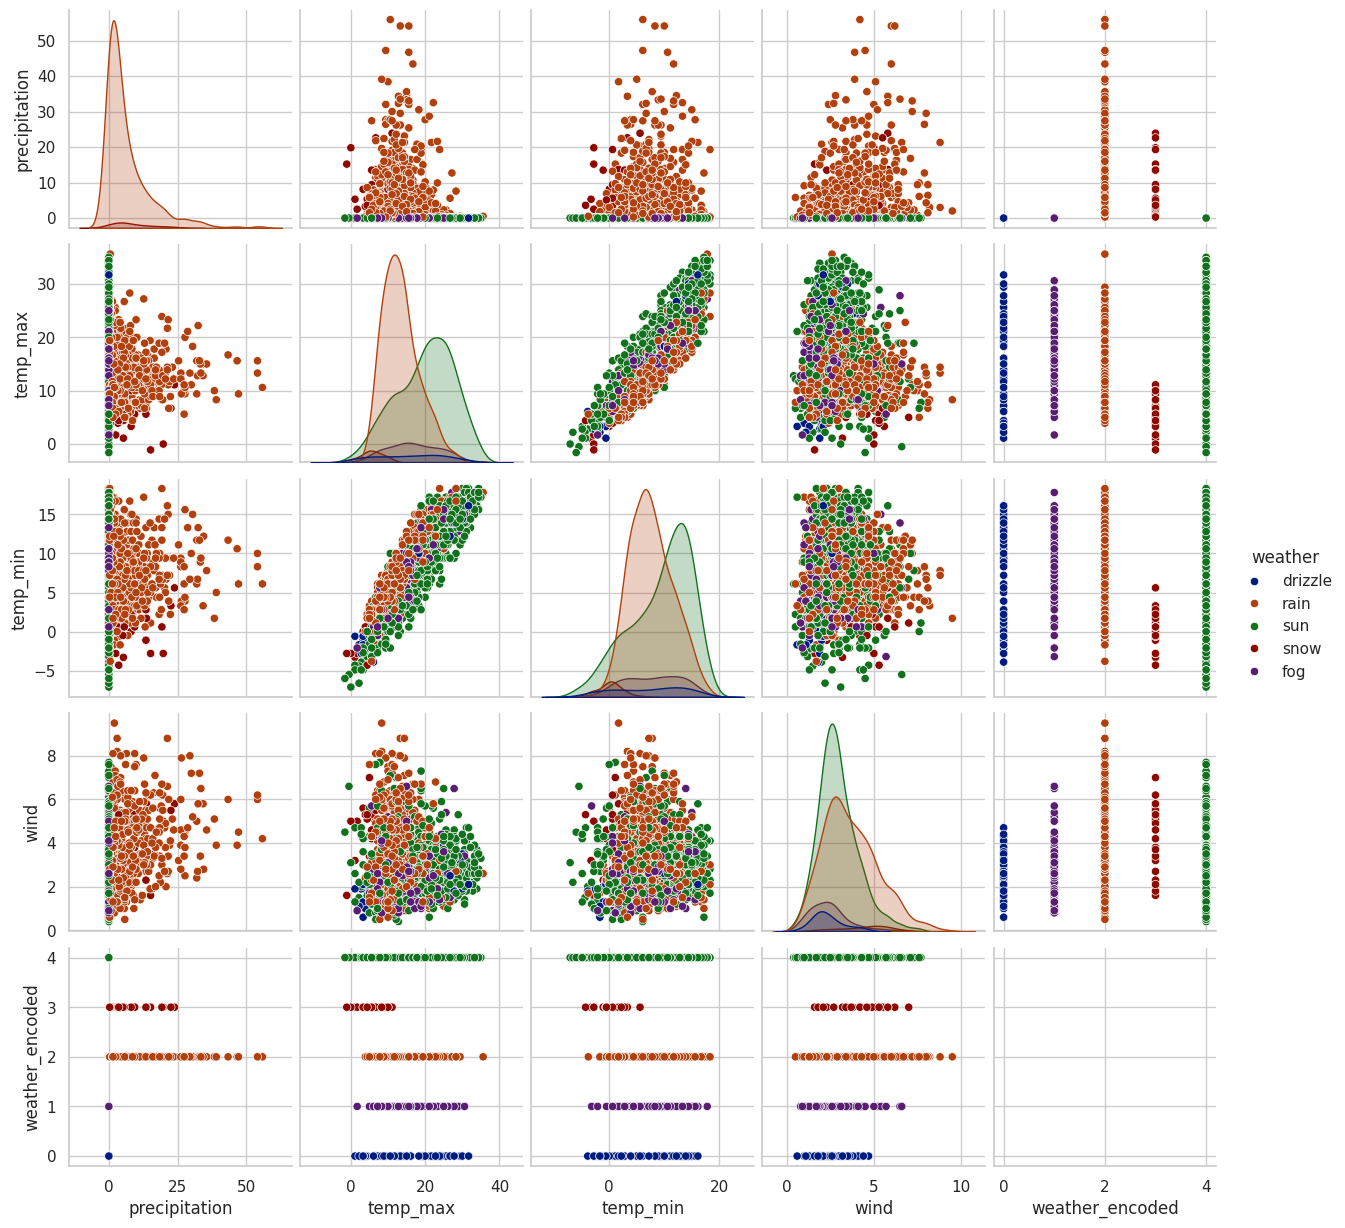

In [11]:
sns.pairplot(data=df, hue='weather', palette='dark')
plt.show()

In [15]:
import plotly.express as px

fig = px.histogram(df,
                   x='weather',
                   barmode='group',
                   color='weather',
                   text_auto=True)

fig.update_layout(title='Distribution of Weather Conditions',
                  title_font={'size':30},
                  showlegend=True)

fig.update_yaxes(showgrid=False)

fig.show()

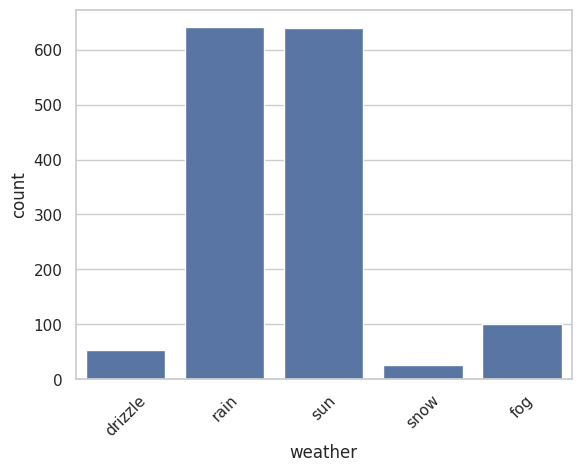

In [16]:
#Distribution df weather types
sns.countplot(x='weather', data=df)
plt.xticks(rotation=45)
plt.show()

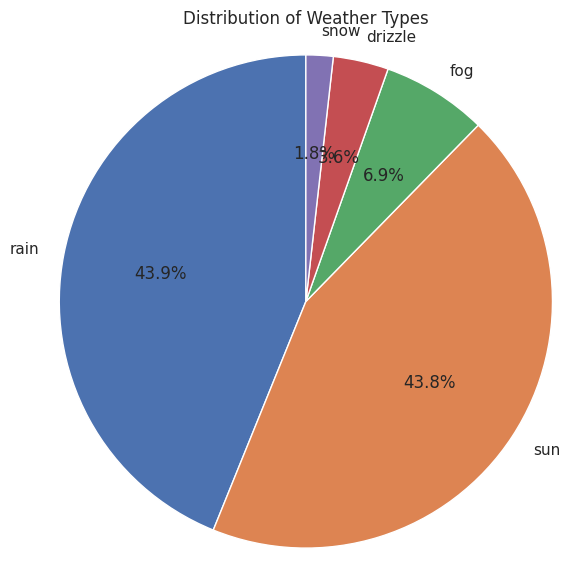

In [17]:
# Count each weather type
weather_counts = df['weather'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    weather_counts,
    labels=weather_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Weather Types")
plt.axis('equal')
plt.show()

/tmp/ipython-input-1100/4007481121.py:26: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-1100/4007481121.py:26: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



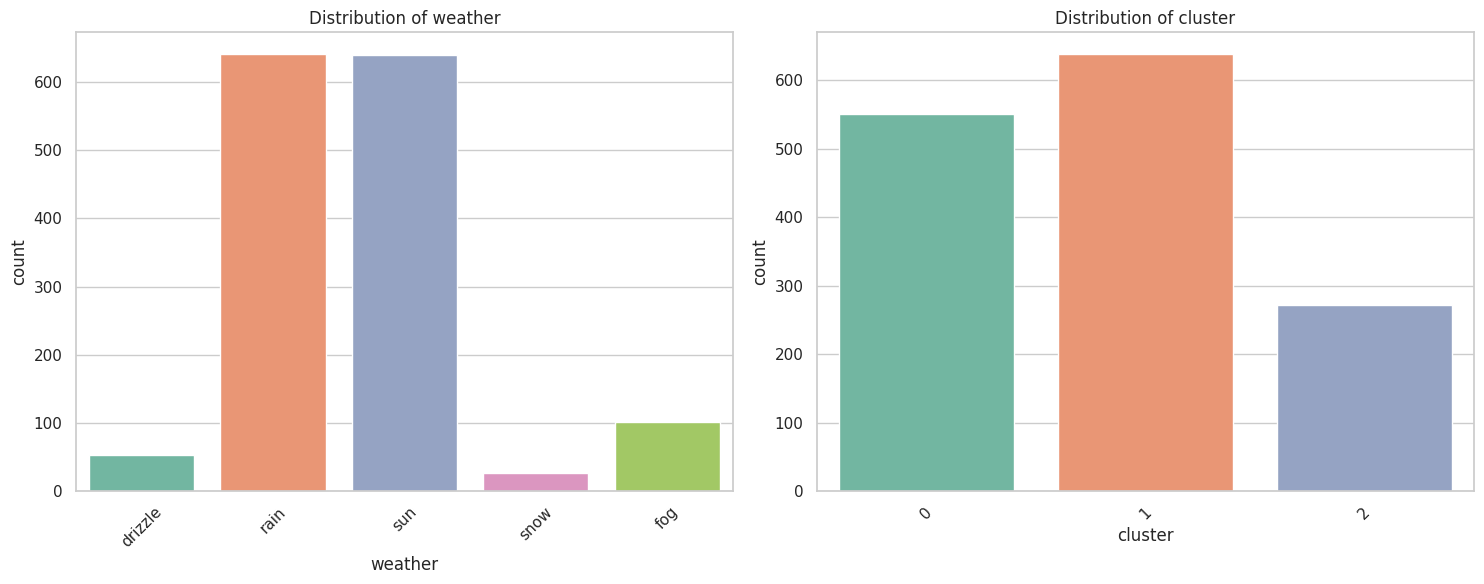

In [18]:
from sklearn.cluster import KMeans
# Check if 'cluster' column exists, if not, create it
if 'cluster' not in df.columns:
    # Define features for clustering (assuming df is available)
    features = ['precipitation', 'temp_max', 'temp_min', 'wind']
    X = df[features]

    # Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform KMeans clustering
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)

    # Add cluster labels to the DataFrame
    df['cluster'] = clusters

cat_cols = ['weather', 'cluster']   # categorical columns

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,6))
axs = axs.flatten()

for i, var in enumerate(cat_cols):
    sns.countplot(x=var, data=df, ax=axs[i], hue=var, palette='Set2', legend=False)
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=45)
    axs[i].set_title(f"Distribution of {var}")

fig.tight_layout()
plt.show()

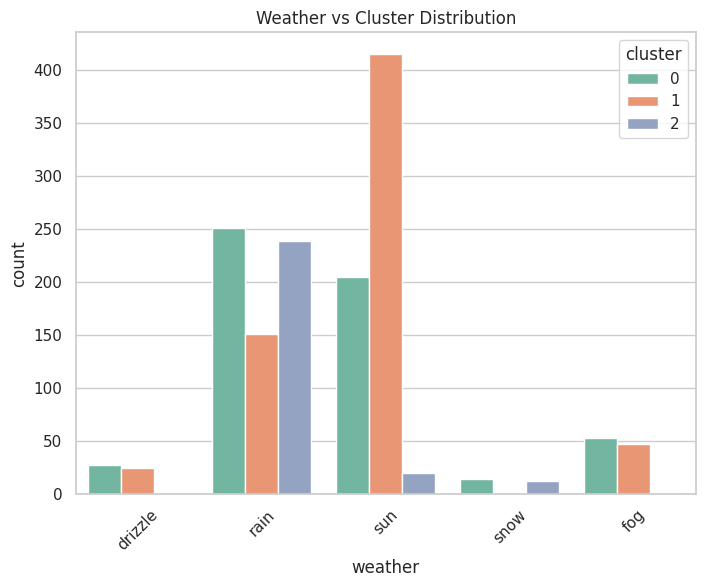

In [19]:
#Weather vs cluster
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(8,6))

sns.countplot(
    x='weather',
    hue='cluster',
    data=df,
    palette='Set2'
)

plt.xticks(rotation=45)
plt.title("Weather vs Cluster Distribution")
plt.show()

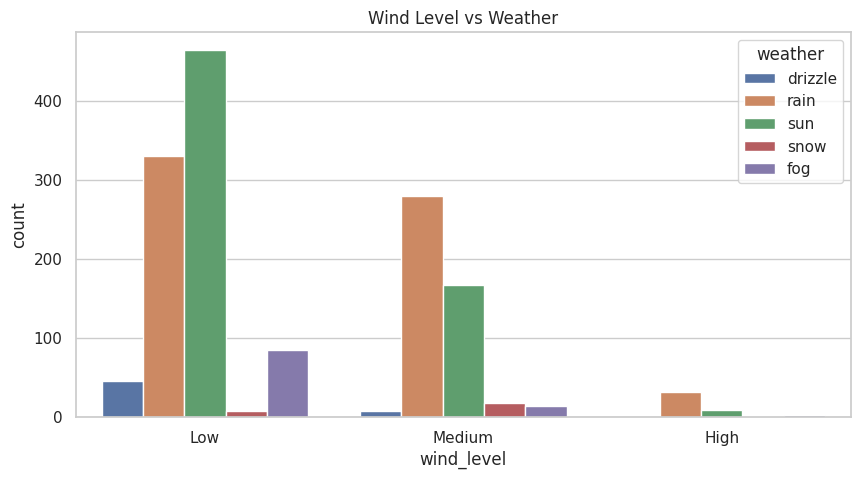

In [20]:
# Ensure 'wind_level' column exists
if 'wind_level' not in df.columns:
    df['wind_level'] = pd.cut(
        df['wind'],
        bins=3,
        labels=['Low','Medium','High']
    )

#count plot
plt.figure(figsize=(10,5))

sns.countplot(
    x='wind_level',
    hue='weather',
    data=df
)

plt.title("Wind Level vs Weather")
plt.show()

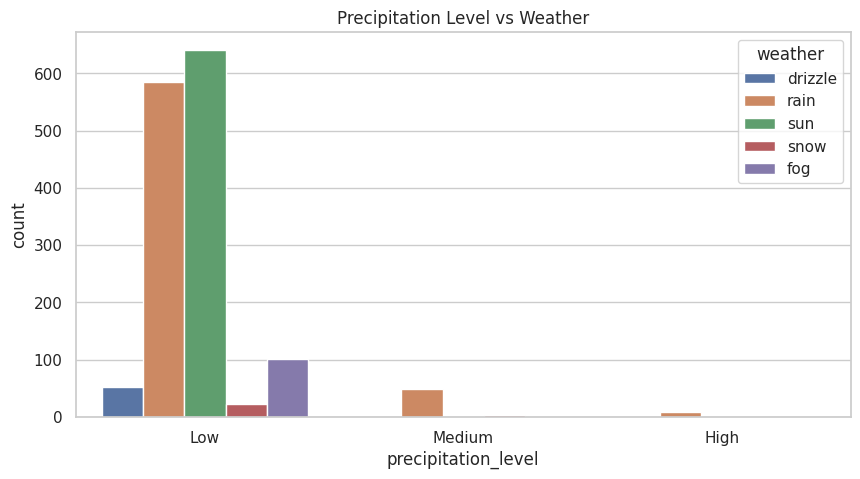

In [21]:
#Precipitation Level vs Weather
df['precipitation_level'] = pd.cut(
    df['precipitation'],
    bins=3,
    labels=['Low','Medium','High']
)

plt.figure(figsize=(10,5))

sns.countplot(
    x='precipitation_level',
    hue='weather',
    data=df
)

plt.title("Precipitation Level vs Weather")
plt.show()

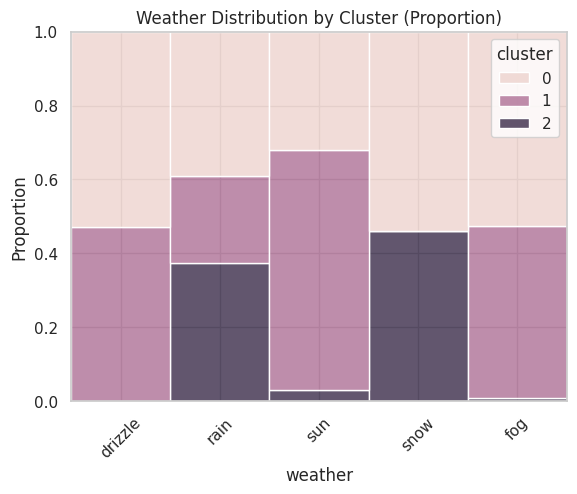

In [22]:
#Weather Type Distribution by Cluster (Percentage Fill)

sns.histplot(
    x='weather',
    hue='cluster',
    data=df,
    multiple='fill',   # percentage depends
    kde=False,
    element='bars'
)

plt.xticks(rotation=45)
plt.title("Weather Distribution by Cluster (Proportion)")
plt.ylabel("Proportion")
plt.show()

/tmp/ipython-input-1100/1721124401.py:23: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-1100/1721124401.py:23: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-1100/1721124401.py:23: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



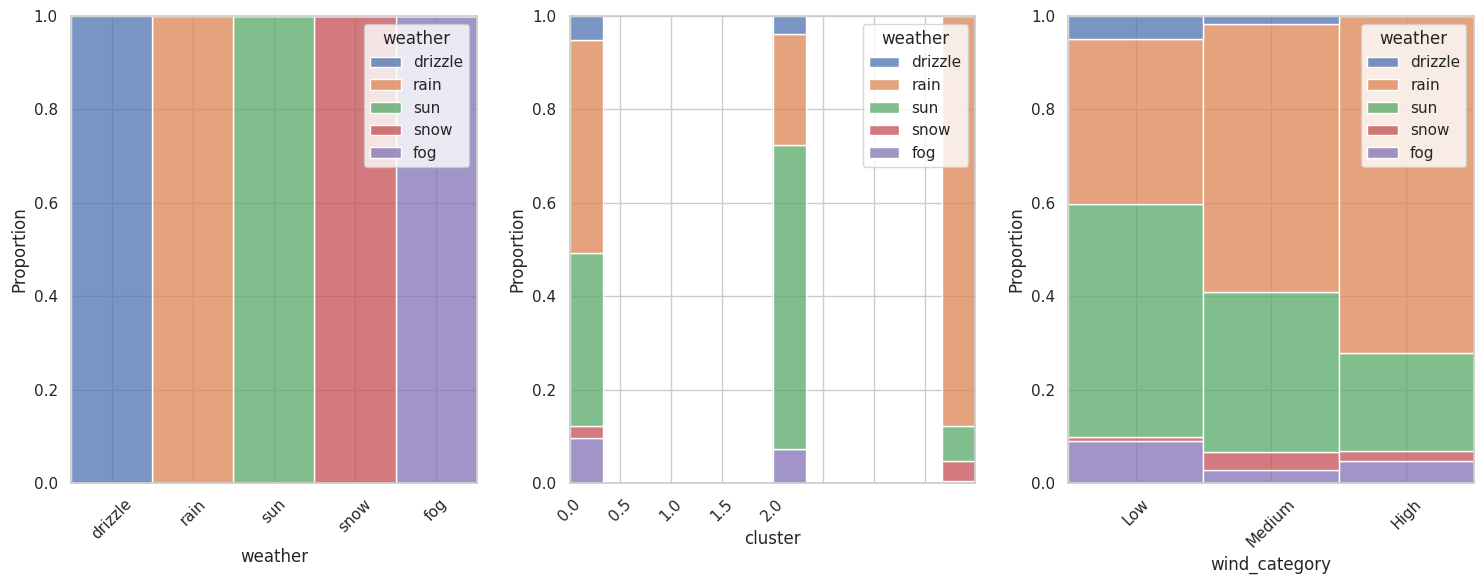

In [23]:
#Wind category and histogram loop
df['wind_category'] = pd.cut(
    df['wind'],
    bins=3,
    labels=['Low','Medium','High']
)
cat_cols = ['weather', 'cluster', 'wind_category']

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,6))
axs = axs.flatten()

for i, var in enumerate(cat_cols):
    sns.histplot(
        x=var,
        hue='weather',
        data=df,
        ax=axs[i],
        multiple='fill',   # percentage style
        kde=False,
        element='bars'
    )

    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=45)
    axs[i].set_xlabel(var)
    axs[i].set_ylabel("Proportion")

fig.tight_layout()
plt.show()

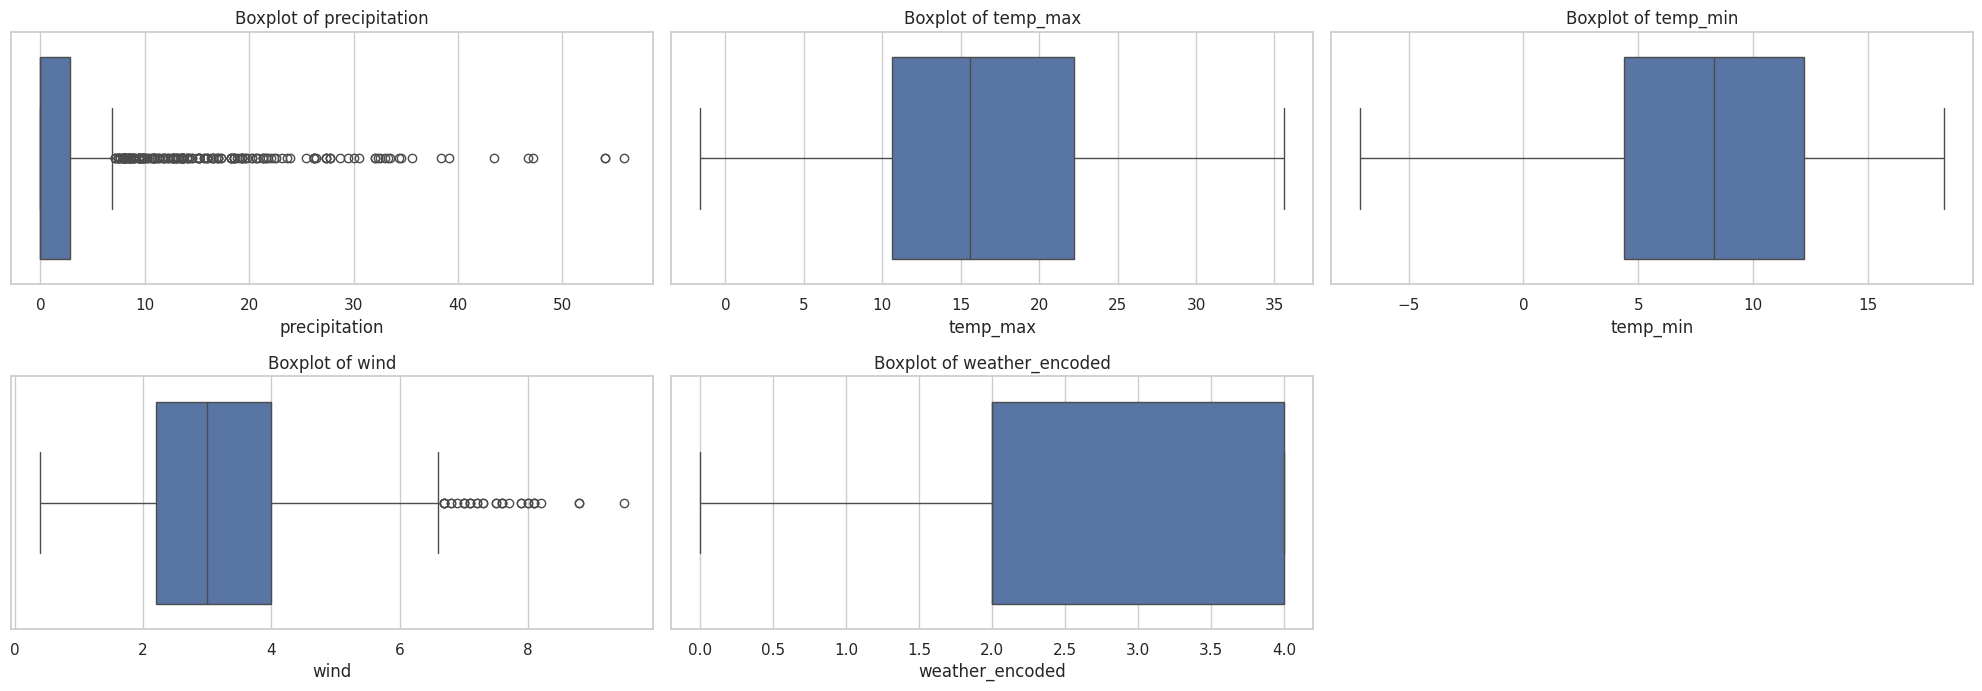

In [24]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(20,10))
axs = axs.flatten()

for i, var in enumerate(num_cols):
    sns.boxplot(x=var, data=df, ax=axs[i])
    axs[i].set_title(f"Boxplot of {var}")

for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

/tmp/ipython-input-1100/1969116741.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-1100/1969116741.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-1100/1969116741.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-1100/1969116741.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-1100/1969116741.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



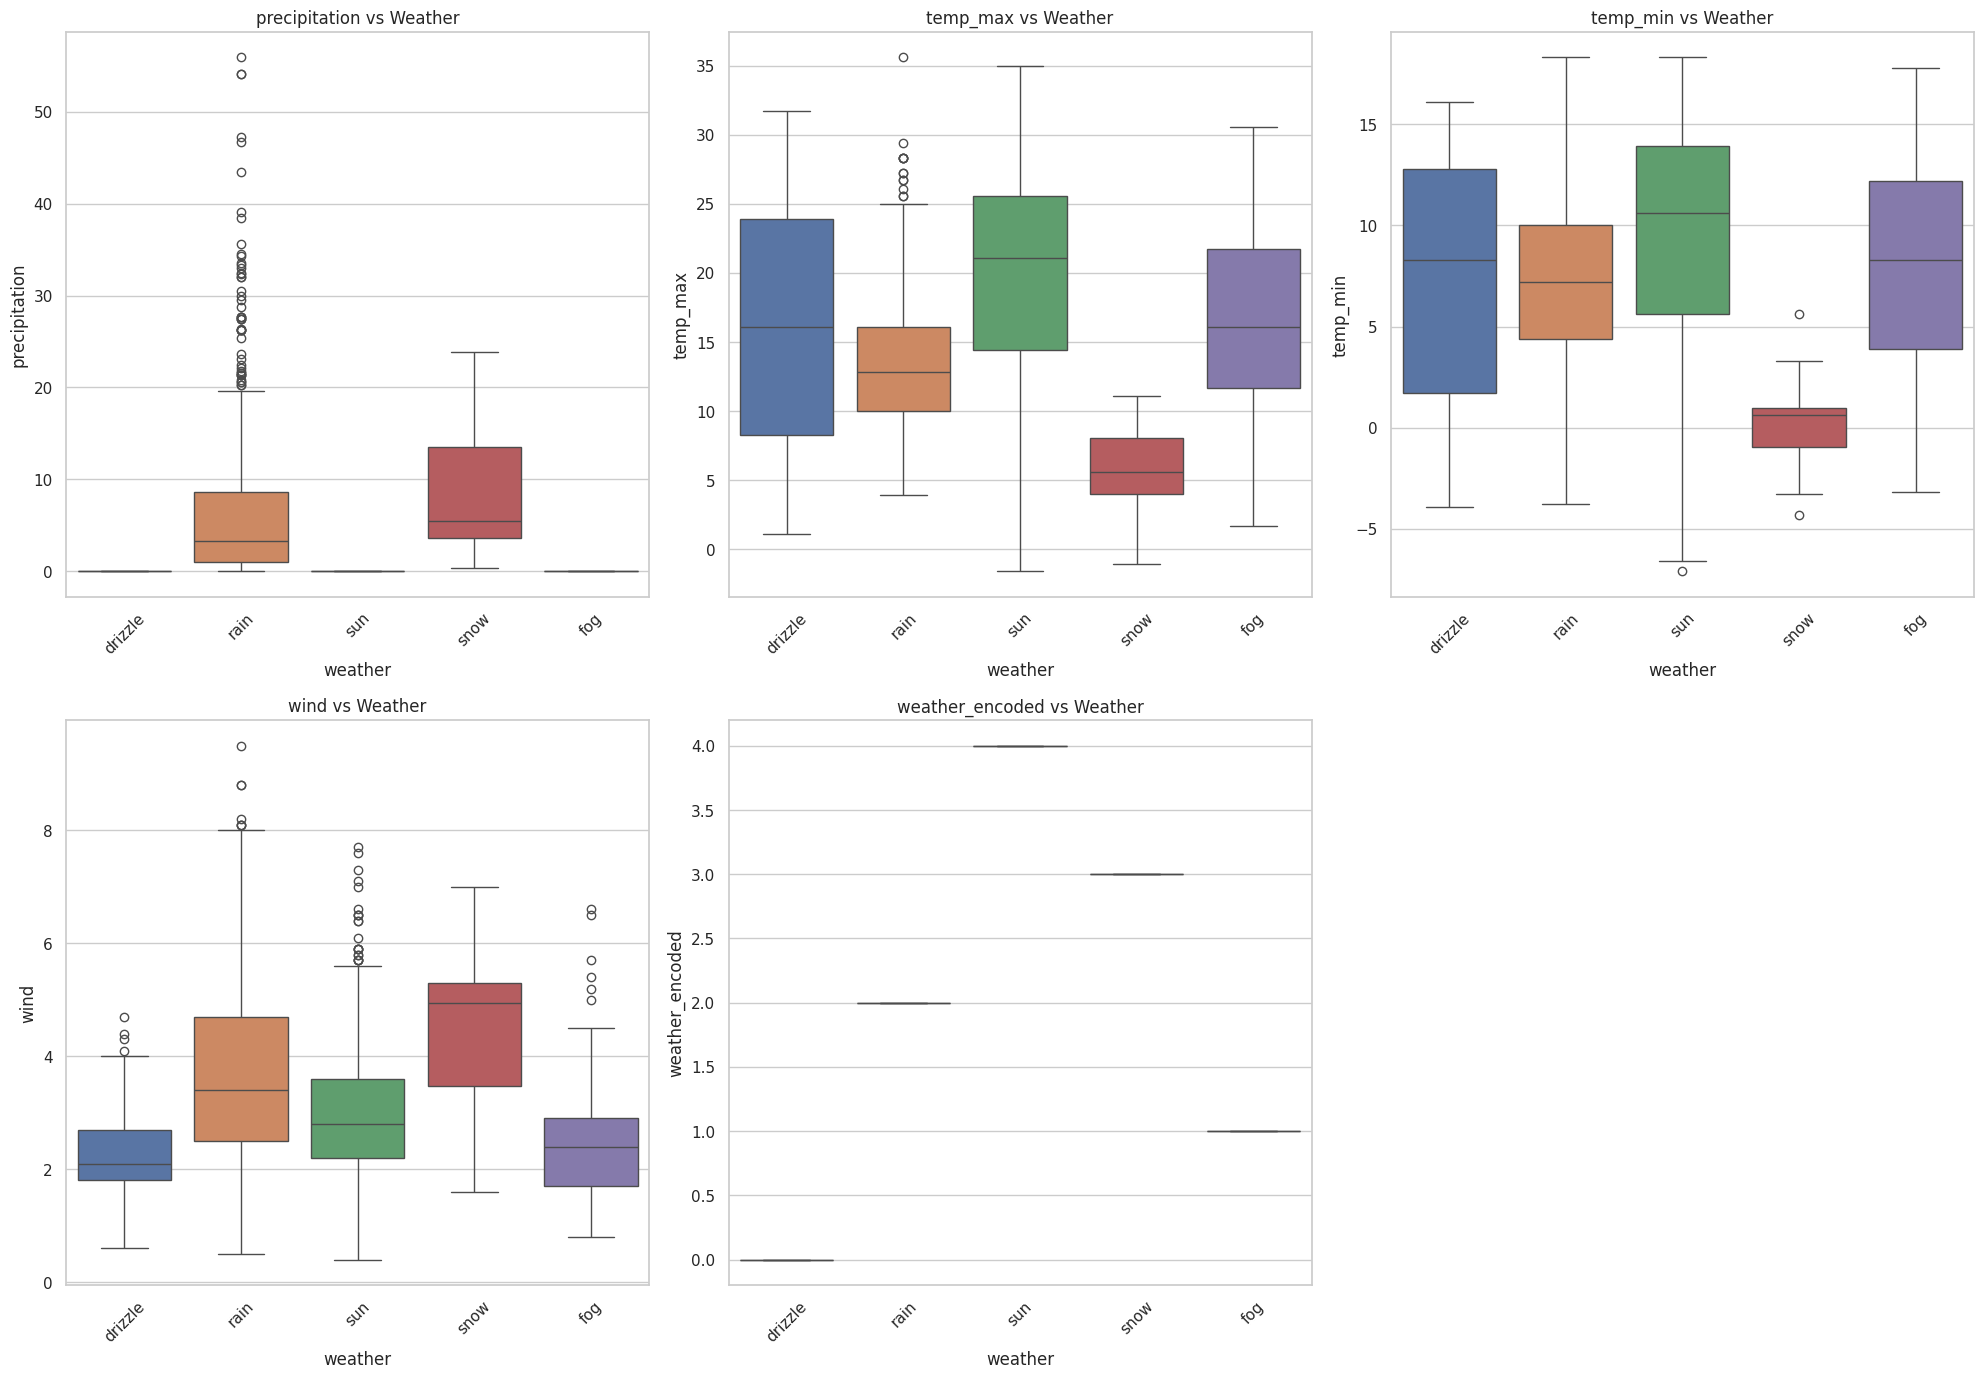

In [25]:
#Boxlplot of Numerical features vs weather

num_cols = df.select_dtypes(include=['int64','float64']).columns

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(20,20))
axs = axs.flatten()

for i, var in enumerate(num_cols):
    sns.boxplot(
        y=var,
        x='weather',
        hue='weather',
        data=df,
        ax=axs[i],
        legend=False
    )
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=45)
    axs[i].set_title(f"{var} vs Weather")


for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

/tmp/ipython-input-1100/1896653685.py:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-1100/1896653685.py:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-1100/1896653685.py:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-1100/1896653685.py:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



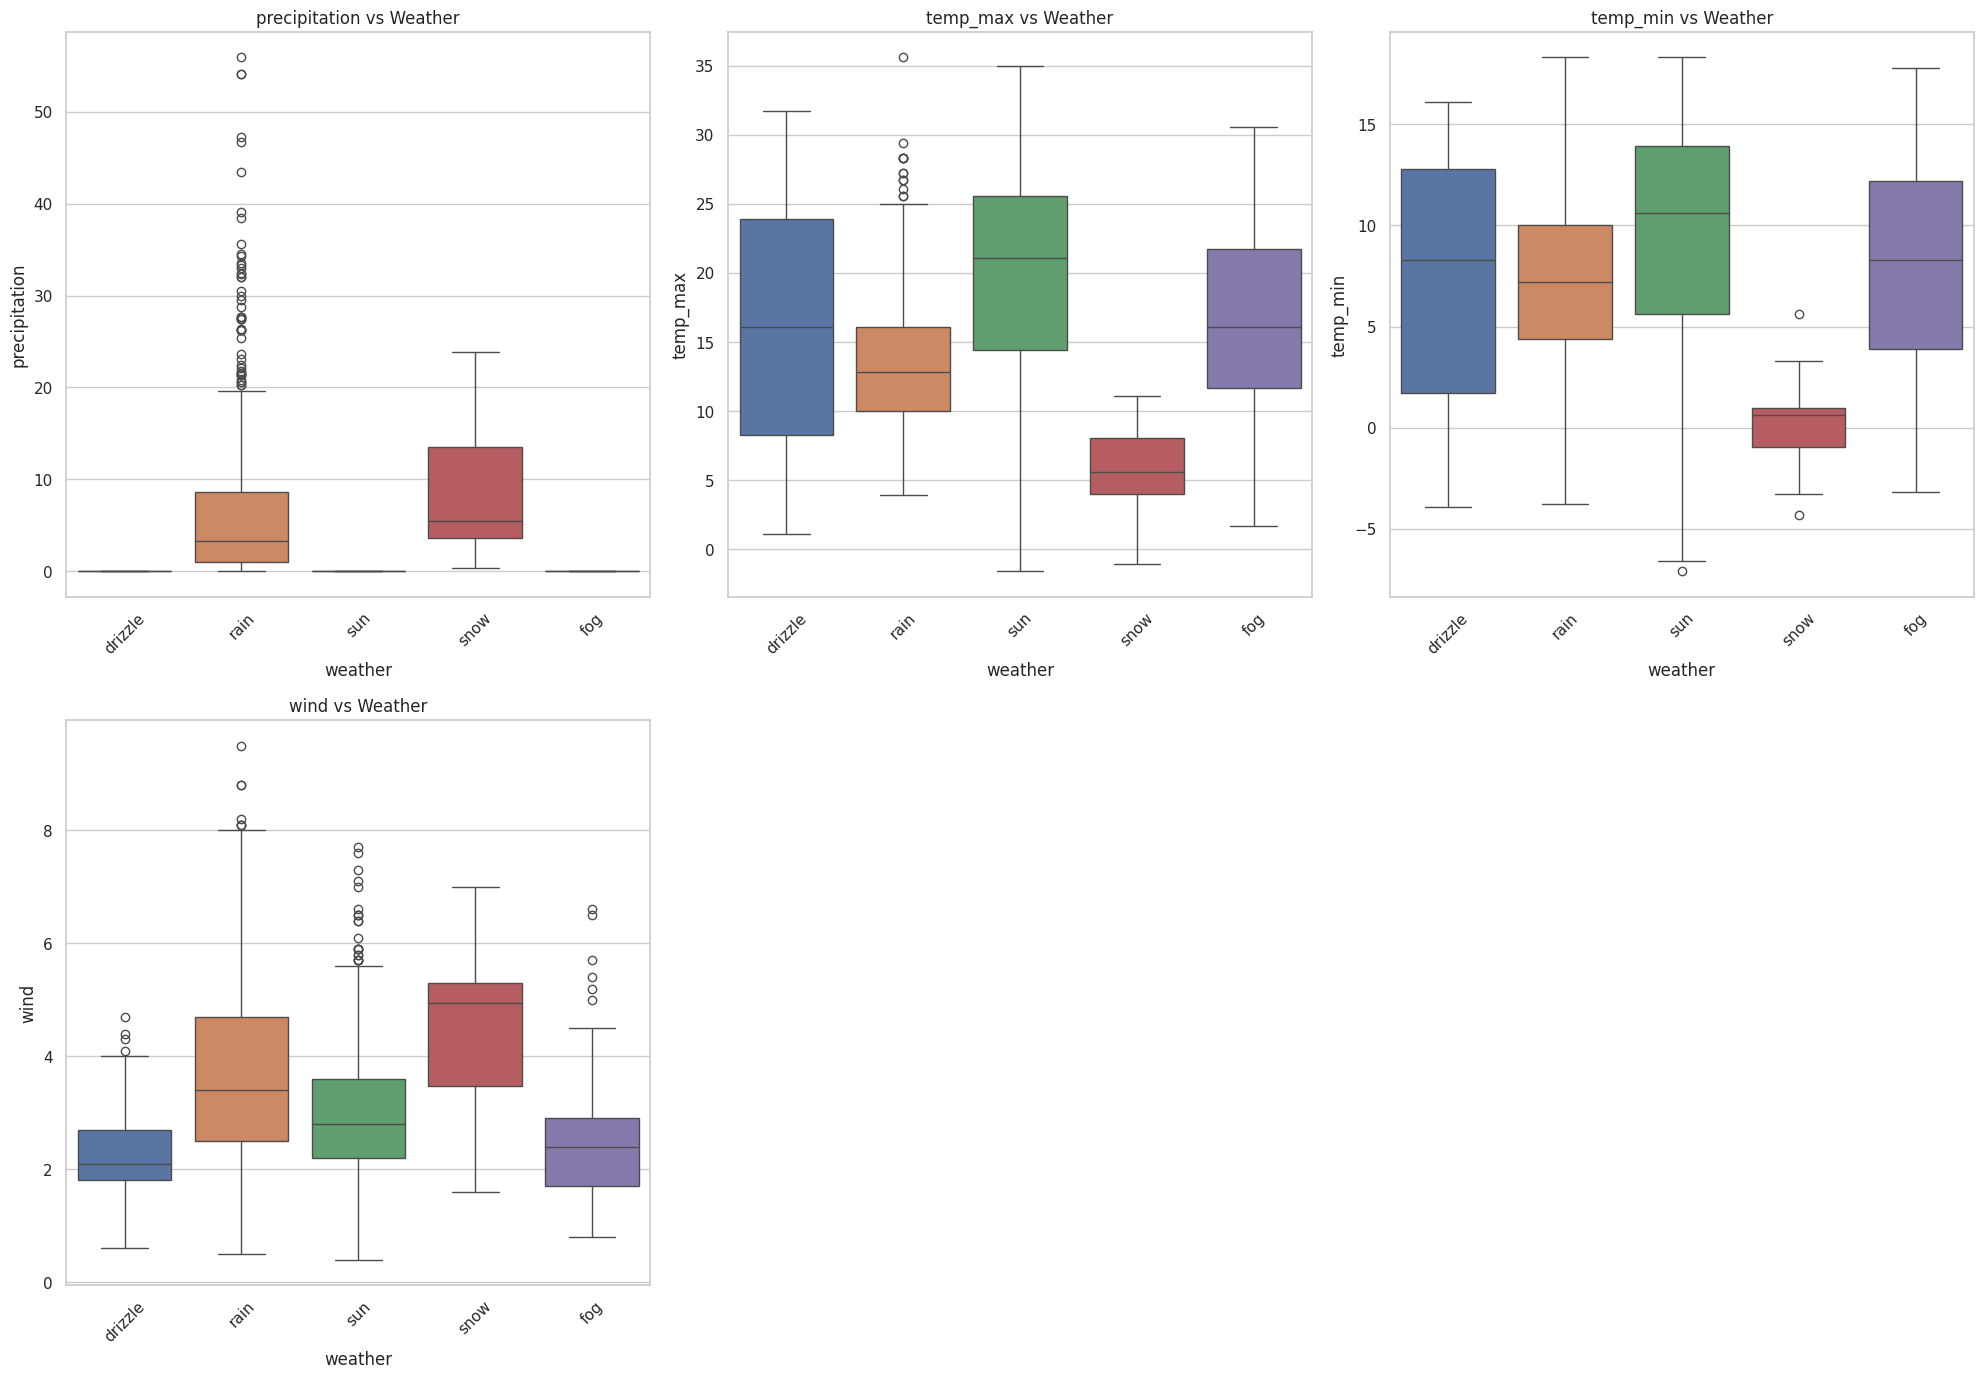

In [26]:
# Boxplot of Numerical features vs weather (without weather_encoded)

num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('weather_encoded')   # এটা বাদ দিলাম

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(20,20))
axs = axs.flatten()

for i, var in enumerate(num_cols):
    sns.boxplot(
        y=var,
        x='weather',
        hue='weather',
        data=df,
        ax=axs[i],
        legend=False
    )
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=45)
    axs[i].set_title(f"{var} vs Weather")

for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

/tmp/ipython-input-1100/2163398759.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



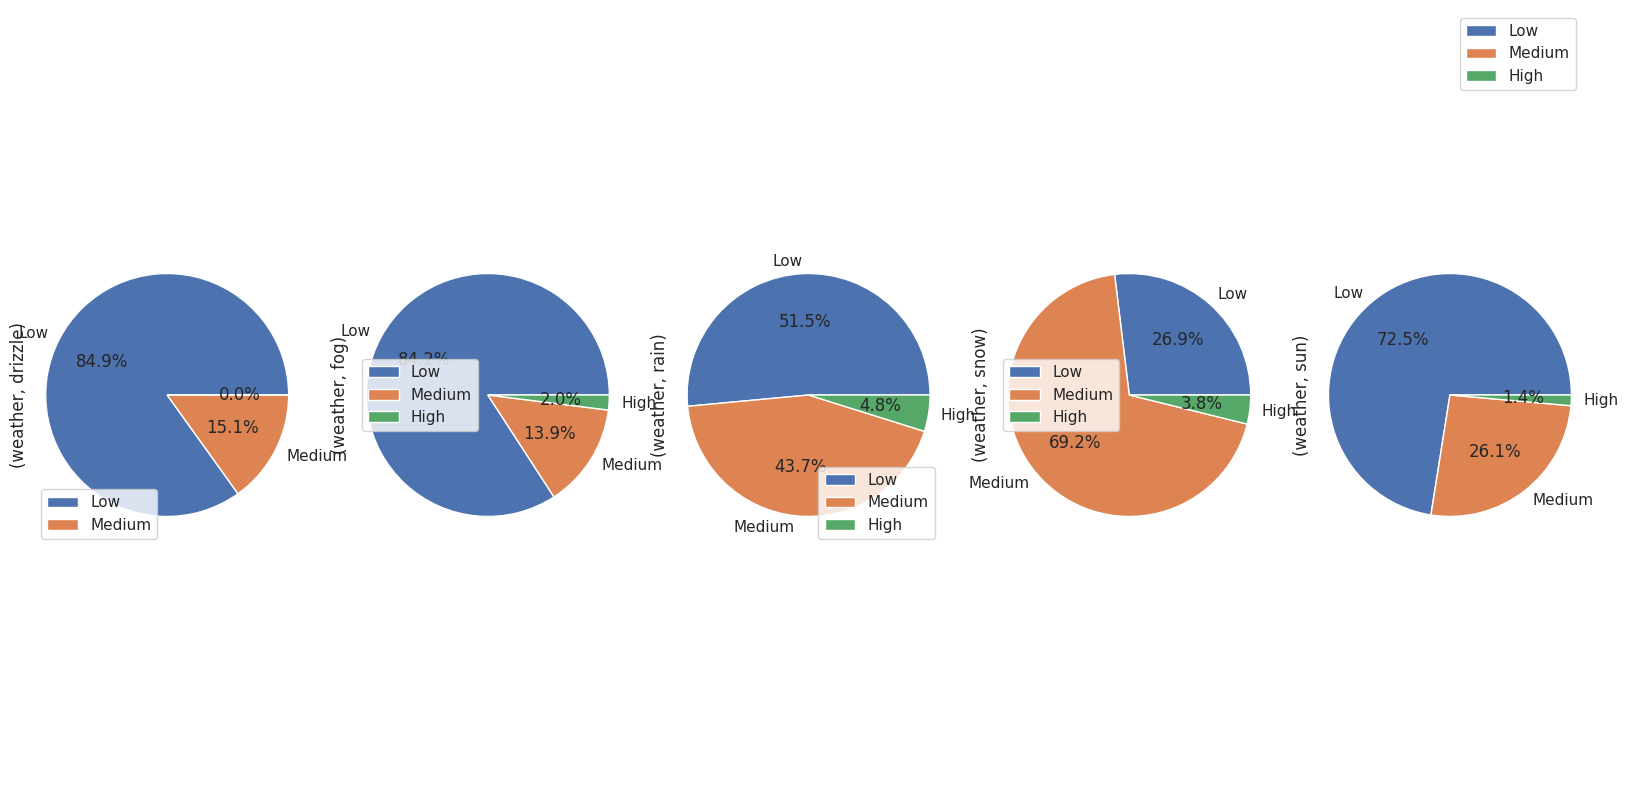

In [27]:
#pivot & pie
df.pivot_table(
    index='wind_level',
    columns='weather',
    aggfunc={'weather':'count'}
).plot.pie(
    autopct='%1.1f%%',
    subplots=True,
    figsize=(20,10)
)

plt.axis('equal')
plt.show()

In [28]:
df.isnull().sum()

,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0
weather_encoded,0
cluster,0
wind_level,0
precipitation_level,0


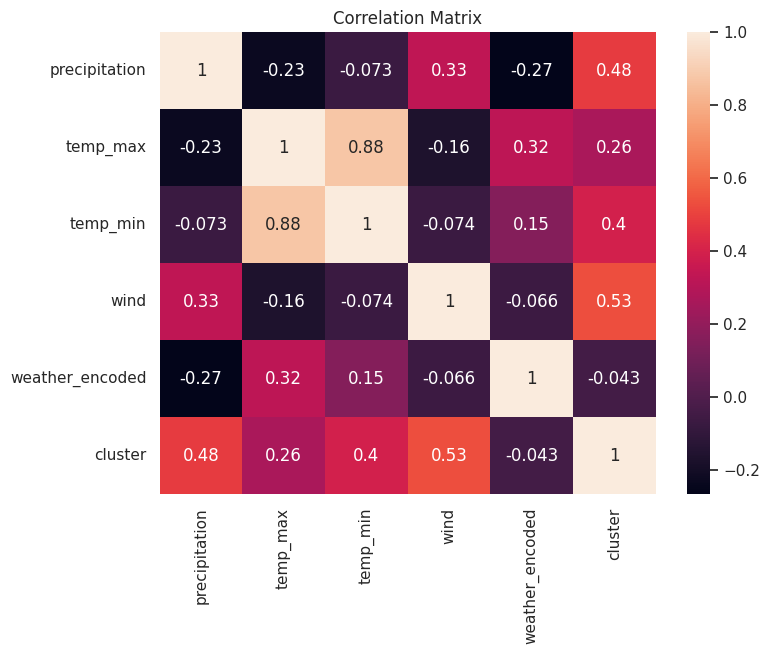

In [29]:
#correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

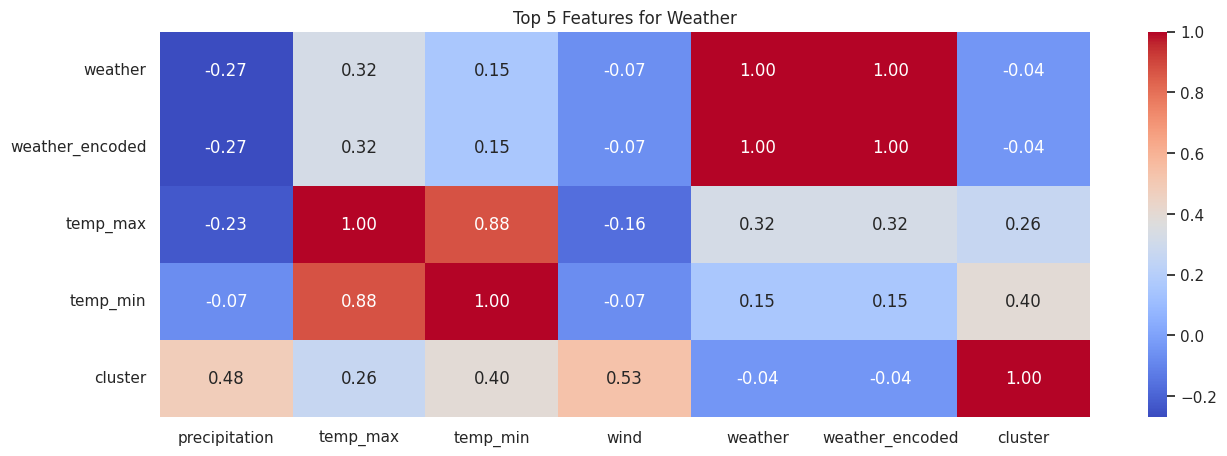

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['weather'] = le.fit_transform(df['weather'])

# correlation matrix
corr = df.corr(numeric_only=True)
max_5_corr = corr.nlargest(5, 'weather')

plt.figure(figsize=(15,5))
sns.heatmap(max_5_corr, fmt='.2f', annot=True, cmap='coolwarm')
plt.title('Top 5 Features for Weather')
plt.show()